In [2]:
from google.colab import files
uploaded = files.upload()

Saving Client.csv to Client.csv
Saving Record.csv to Record.csv


1. جاري تحميل ودمج البيانات...
2. جاري تنظيف البيانات وتحضيرها للموديل...
3. جاري تدريب موديل الذكاء الاصطناعي (Random Forest)...

=== نتايج تقييم الموديل (Evaluation Metrics) ===
اسم الموديل المستحدم: Random Forest Classifier
نسبة الدقة (Accuracy): 0.6075
درجة الـ ROC-AUC Score: 0.6487


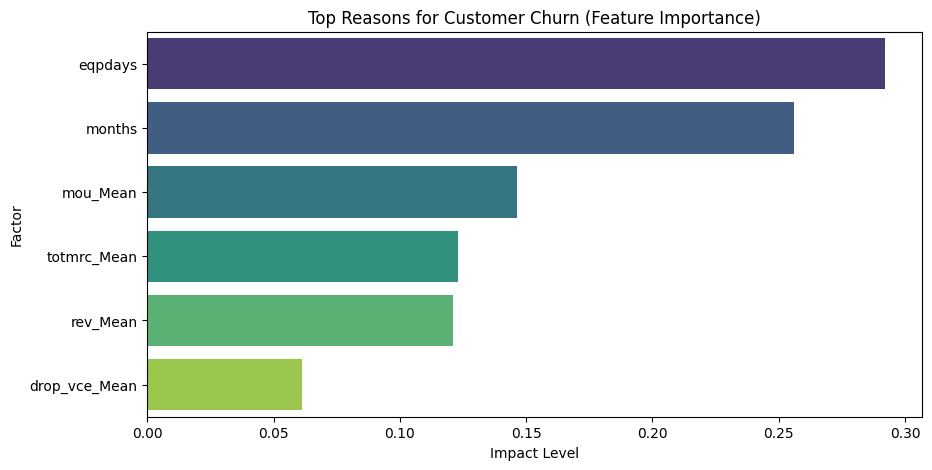

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("1. جاري تحميل ودمج البيانات...")
# تحميل الملفات
client_df = pd.read_csv('Client.csv')
record_df = pd.read_csv('Record.csv')
# دمج الملفات بناءً على رقم العميل
df = pd.merge(client_df, record_df, on='Customer_ID', how='inner')
print("2. جاري تنظيف البيانات وتحضيرها للموديل...")
df_model = df.drop(columns=['Customer_ID'])
# اختيار أهم الأعمدة لتسريع التشغيل
features_to_keep = ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'drop_vce_Mean', 'months', 'eqpdays', 'churn']
df_model = df_model[features_to_keep]

# تعويض القيم المفقودة
imputer = SimpleImputer(strategy='median')
df_model[df_model.columns] = imputer.fit_transform(df_model)

# تقسيم البيانات لتدريب الموديل
X = df_model.drop('churn', axis=1)
y = df_model['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("3. جاري تدريب موديل الذكاء الاصطناعي (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=10, n_jobs=-1)
rf_model.fit(X_train, y_train)

# حساب الدقة
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n=== نتايج تقييم الموديل (Evaluation Metrics) ===")
print(f"اسم الموديل المستحدم: Random Forest Classifier")
print(f"نسبة الدقة (Accuracy): {accuracy:.4f}")
print(f"درجة الـ ROC-AUC Score: {roc_auc:.4f}")

# رسم أهم الأسباب لهروب العملاء
feature_importances = pd.DataFrame({'العامل': X.columns, 'الأهمية': rf_model.feature_importances_}).sort_values(by='الأهمية', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='الأهمية', y='العامل', data=feature_importances, palette='viridis')
plt.title('Top Reasons for Customer Churn (Feature Importance)')
plt.xlabel('Impact Level')
plt.ylabel('Factor')
plt.show()